# Etna Cause–Trigger Analysis

This notebook applies the Cause–Trigger analysis to the Etna case. **HMML is the baseline causal-discovery method**; PCMCI and PCMCI+ are extensions. PCMCI+ additionally evaluates eligible directed same-hour links (tau=0) as trigger candidates while retaining lagged variables for the causal component used to construct \(V\).

The main analysis uses maximum lag orders \(d=1,...,12\) for every backend. Minimum-\(I_2\) values 36, 48, 60 and 72 h assess partition stability.

Minimum-\(I_2\) settings that generate the same split are **not treated as independent replications**. The backend × lag grid is executed once per unique partition, while all supporting minimum-\(I_2\) values remain recorded in the audit output.

The target effect is anomalous local catalogue seismicity. Moderation decisions use alpha=0.05; case-wide Benjamini–Hochberg values are saved as a secondary multiplicity audit and do not replace the original F-test decision rule. A hierarchical interaction model and Newey–West/HAC inference at 6, 12 and 24 h are evaluated as sensitivity checks only.

## Configuration

In [1]:
from pathlib import Path
import sys

import pandas as pd

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cause_trigger_reporting import (
    automatic_lag_outcome_table,
    backend_split_summary,
    export_audit_csvs,
    mean_shift_role_table,
    moderation_summary,
    multiplicity_audit_summary,
    pair_split_lag_summary,
    plot_effect_with_splits,
    plot_mean_shift_roles,
    plot_moderation_heatmap,
    plot_pair_stability_heatmap,
    run_unique_split_grid,
    show_table,
    split_display_table,
    warning_pattern_summary,
    warning_summary,
)
from cause_trigger_workflow import (
    COMPACT_RUN_SPECS,
    prepare_case_analysis,
    run_one,
)

from cause_trigger_cases import ETNA_CASE

CASE = ETNA_CASE
EFFECT = CASE.effect
VARIABLE_LABELS = CASE.variable_labels

DATA_PATH = PROJECT_ROOT / "data/etna/etna_dataset.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

SAVE_RESULTS = True
SHOW_FULL_GRID = False
SHOW_SCALING_REPORT = False

EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")
EVENT_LABEL = "Wenchuan earthquake origin time"

CASE_PRE_DAYS = 7
CASE_POST_DAYS = 4
REFERENCE_DAYS = 14
REFERENCE_MIN_COVERAGE = 0.90

MIN_I1_LENGTH = 72
MIN_I2_GRID = (36, 48, 60, 72)
LAG_GRID = tuple(range(1, 13))

ALPHA = 0.05
PCMCI_PC_ALPHA = 0.2
PCMCI_PLUS_PC_ALPHA = 0.01
PCMCI_ALPHA_LEVEL = 0.05
PCMCI_FDR_METHOD = "fdr_bh"
COND_IND_TEST = "robust_parcorr"
HAC_LAGS = (6, 12, 24)

## Data preparation and partition stability

The causal interval contains **7 days before** and **4 days after** the contextual event hour. The preceding 14-day reference interval is used only for transformation parameters and reference-standardised mean comparisons; it is not included in \(I_1\) or \(I_2\). The mean-shift figure reports the algorithm's screening and ranking quantities; these are not estimates of physical effect size or causal strength.


Item,Value
Dataset coverage,2008-04-11 14:00:00+00:00 to 2008-05-19 06:00:00+00:00 (905 retained hourly rows)
Causal-analysis interval,"[2008-05-05 06:00:00+00:00, 2008-05-16 06:00:00+00:00) (264 h; 7 d before and 4 d after the event hour)"
Reference-standardisation interval,"[2008-04-21 06:00:00+00:00, 2008-05-05 06:00:00+00:00); 336/336 h (100.0% coverage)"
Wenchuan earthquake origin time,2008-05-12 06:28:00+00:00
Effect maximum,2008-05-13 13:00:00+00:00 (1 days 06:32:00 from event)
Minimum interval design,"I1 >= 72 h; minimum-I2 grid = (36, 48, 60, 72) h"
Maximum-lag-order design,"d = 1-12 h for HMML, PCMCI, and PCMCI+"
PCMCI extension settings,PCMCI pc_alpha=0.2; PCMCI+ graph pc_alpha=0.01; lagged-link alpha=0.05; lagged-link FDR=fdr_bh; PCMCI+ tau=0 links exploratory without BH adjustment; conditional-independence test=robust_parcorr
Moderation sensitivity,"Primary non-hierarchical F-test retained as primary; hierarchical interaction model with trigger main effect and Newey--West sensitivity at maximum lags (6, 12, 24) h"
Unique split partitions,1 unique causal partition(s) from 4 causal minimum-I2 settings;


Minimum I2 (h),Causal grid,Partition,Split time,I1 (h),I2 (h),Split score,Boundary split,Offset from event
36,True,S1,2008-05-13 02:00:00+00:00,188,76,0.680640,False,0 days 19:32:00
48,True,S1,2008-05-13 02:00:00+00:00,188,76,0.680640,False,0 days 19:32:00
60,True,S1,2008-05-13 02:00:00+00:00,188,76,0.680640,False,0 days 19:32:00
72,True,S1,2008-05-13 02:00:00+00:00,188,76,0.680640,False,0 days 19:32:00


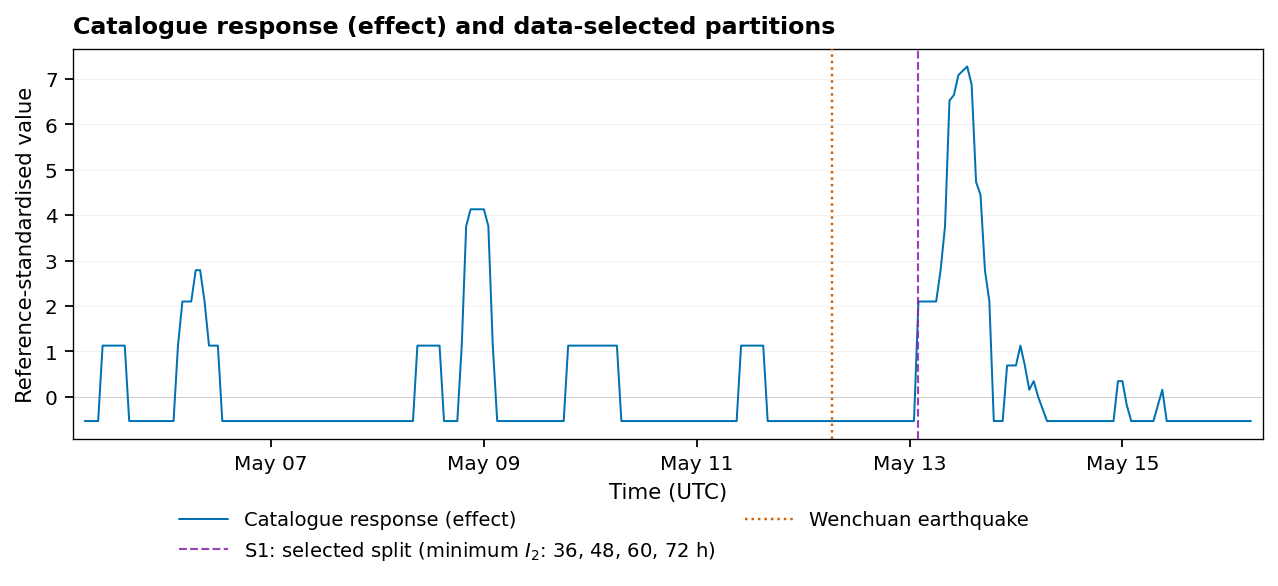

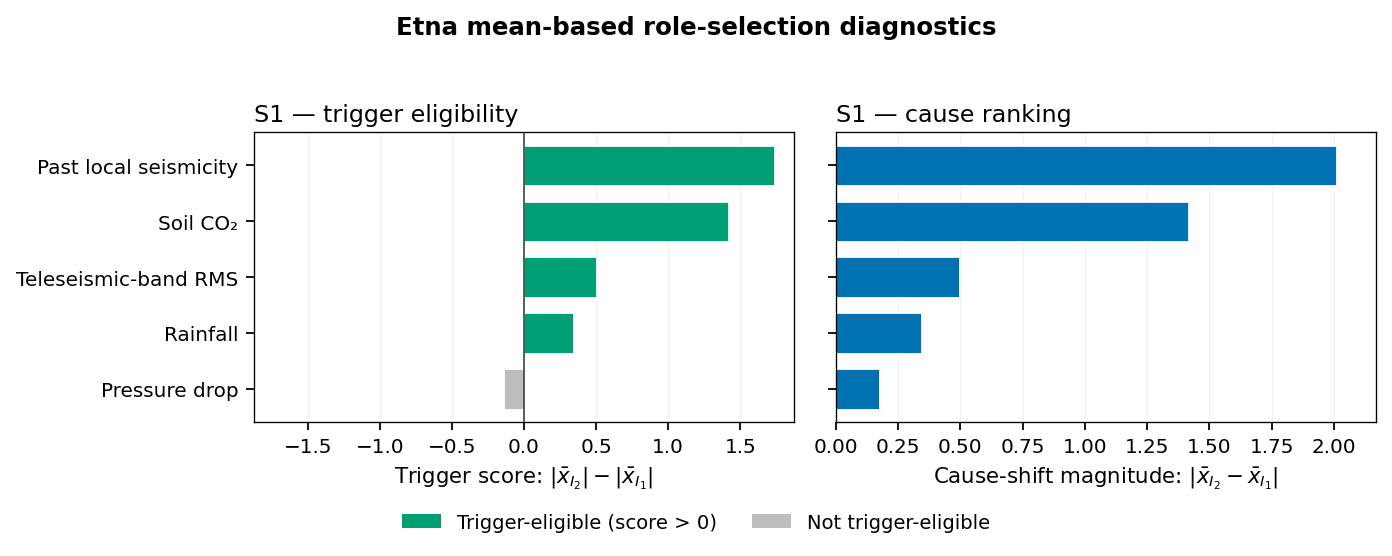

(<Figure size 1408x544 with 2 Axes>,
 array([[<Axes: title={'left': 'S1 — trigger eligibility'}, xlabel='Trigger score: $|\\bar{x}_{I_2}|-|\\bar{x}_{I_1}|$'>,
         <Axes: title={'left': 'S1 — cause ranking'}, xlabel='Cause-shift magnitude: $|\\bar{x}_{I_2}-\\bar{x}_{I_1}|$'>]],
       dtype=object),
 [WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/etna_mean_shift_roles.pdf'),
  WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/etna_mean_shift_roles.png')])

In [2]:
analysis = prepare_case_analysis(
    data_path=DATA_PATH,
    case=CASE,
    event_time=EVENT_TIME,
    event_label=EVENT_LABEL,
    case_pre_days=CASE_PRE_DAYS,
    case_post_days=CASE_POST_DAYS,
    reference_days=REFERENCE_DAYS,
    reference_min_coverage=REFERENCE_MIN_COVERAGE,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_values=MIN_I2_GRID,
    lag_grid=LAG_GRID,
    alpha=ALPHA,
    pcmci_pc_alpha=PCMCI_PC_ALPHA,
    pcmci_plus_pc_alpha=PCMCI_PLUS_PC_ALPHA,
    pcmci_alpha_level=PCMCI_ALPHA_LEVEL,
    pcmci_fdr_method=PCMCI_FDR_METHOD,
    cond_ind_test=COND_IND_TEST,
    hac_lags=HAC_LAGS,
)

show_table(analysis.design_summary, "Final analysis design and timing")
show_table(
    split_display_table(analysis.split_summary),
    "Effect split across causal and split-only minimum-I2 settings",
)

if SHOW_SCALING_REPORT:
    show_table(
        analysis.scaling_report.reset_index(names="Variable"),
        "Transformation and scaling audit",
    )

plot_effect_with_splits(
    analysis.X_mean,
    EFFECT,
    analysis.split_summary,
    event_time=EVENT_TIME,
    effect_label=VARIABLE_LABELS[EFFECT],
    event_label="Wenchuan earthquake",
    filename="etna_effect_splits",
    save_dir=FIGURES_DIR,
)

role_shift_table = mean_shift_role_table(
    analysis.X_mean,
    EFFECT,
    analysis.split_summary,
    variable_labels=VARIABLE_LABELS,
)
plot_mean_shift_roles(
    role_shift_table,
    title="Etna mean-based role-selection diagnostics",
    filename="etna_mean_shift_roles",
    save_dir=FIGURES_DIR,
)

## Cause–Trigger analysis over unique partitions

A maximum order \(d=k\) permits lagged relations from 1 through \(k\) hours. The grid is interpreted through recurrence across adjacent orders, unique partitions, and backends; not by selecting the smallest p-value. The stability heatmap distinguishes pairs that were not selected, selected but not evaluable, fitted without rejecting H₀, supported only by the nominal F-test, and supported after the case-wide BH audit.

For every evaluable candidate, we additionally conduct a sensitivity analysis using the hierarchical interaction model $$(y_t=\gamma_0+ \gamma_1V_{s,t}+\gamma_sx_{s,t}+\gamma_2V_{s,t}x_{s,t}+\varepsilon_t)$$ It reports the ordinary nested F-test and Newey–West/HAC tests of $$(H_0:\gamma_2=0)$$ with maximum covariance lags of 6, 12 and 24 h. Each specification receives its own case-wide BH adjustment. These diagnostics test sensitivity to the trigger main effect and serially correlated residuals; they do not alter the model classifications.

Partition,Minimum-I2 support,Backend,Successful runs,Post-split parent lags,Trigger-candidate lags,Fitted-moderation lags,Nominally supported pair lags,τ=0-link lags,Warning runs,Result
S1,"[36, 48, 60, 72]",HMML (baseline),12/12,12/12,12/12,12/12,12/12,0/12,12/12,Nominally supported pair(s) at 12 maximum-lag order(s)
S1,"[36, 48, 60, 72]",PCMCI,12/12,6/12,6/12,2/12,2/12,0/12,0/12,Nominally supported pair(s) at 2 maximum-lag order(s)
S1,"[36, 48, 60, 72]",PCMCI+ with eligible exploratory τ=0 triggers,12/12,4/12,5/12,0/12,0/12,3/12,0/12,Candidates found; no evaluable moderation model


Backend,Trigger source,Cause,Trigger,Nominally supported cells,BH-supported cells,Partitions,Partition support,Minimum-I2 values,Maximum lag orders,Lag-order support,Longest adjacent lag run
HMML (baseline),Lagged,Past local seismicity,Teleseismic-band RMS,11/12,11/12,['S1'],1/1,"[36, 48, 60, 72]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",11/12,11
HMML (baseline),Lagged,Soil CO₂,Past local seismicity,4/12,4/12,['S1'],1/1,"[36, 48, 60, 72]","[1, 2, 5, 12]",4/12,2
HMML (baseline),Lagged,Past local seismicity,Soil CO₂,3/12,3/12,['S1'],1/1,"[36, 48, 60, 72]","[1, 2, 3]",3/12,3
PCMCI,Lagged,Rainfall,Teleseismic-band RMS,2/12,2/12,['S1'],1/1,"[36, 48, 60, 72]","[8, 9]",2/12,2
HMML (baseline),Lagged,Teleseismic-band RMS,Past local seismicity,2/12,2/12,['S1'],1/1,"[36, 48, 60, 72]","[8, 10]",2/12,1
HMML (baseline),Lagged,Past local seismicity,Rainfall,1/12,1/12,['S1'],1/1,"[36, 48, 60, 72]",[12],1/12,1
PCMCI,Lagged,Teleseismic-band RMS,Rainfall,1/12,1/12,['S1'],1/1,"[36, 48, 60, 72]",[9],1/12,1


Fitted moderation tests,Nominal F-test support,BH-supported
36,24,24


Specification,Fitted tests,Nominally supported,BH-supported,Retained among original model support,Same interaction sign as the original model
Primary model,36,24,24,24/24,24/24
Hierarchical OLS,36,21,21,20/24,22/24
HAC-6 h,36,21,19,19/24,22/24
HAC-12 h,36,20,19,18/24,22/24
HAC-24 h,36,22,21,20/24,22/24


Partition,Backend,Maximum lag orders,Runs,Warning count,Scope,Fitted moderation tests,Nominal F-test support,BH-supported,Execution errors,Warning pattern
S1,HMML (baseline),"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,265,"complete backend run, including parent search",27,18,18,0,invalid value encountered in scalar divide
S1,HMML (baseline),"[11, 12]",2,34,"complete backend run, including parent search",5,3,3,0,"invalid value encountered in scalar divide; divide by zero encountered in scalar divide; Perfect separation or prediction detected, parameter may not be identified"


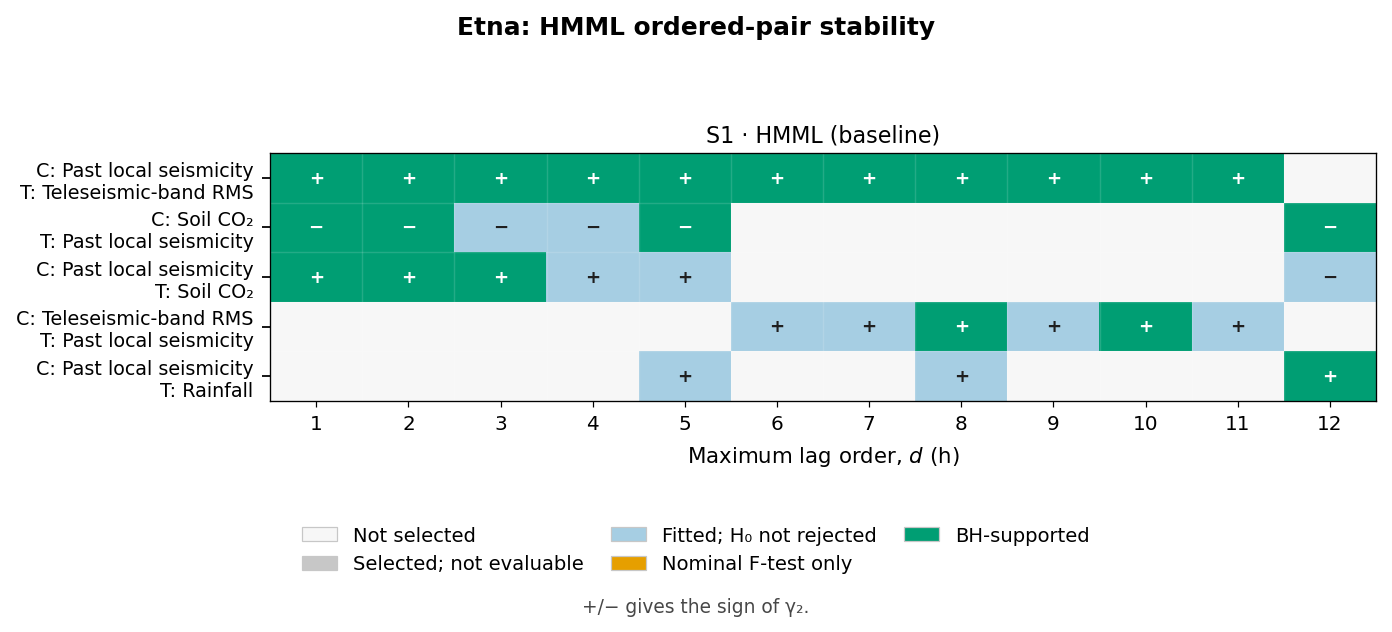

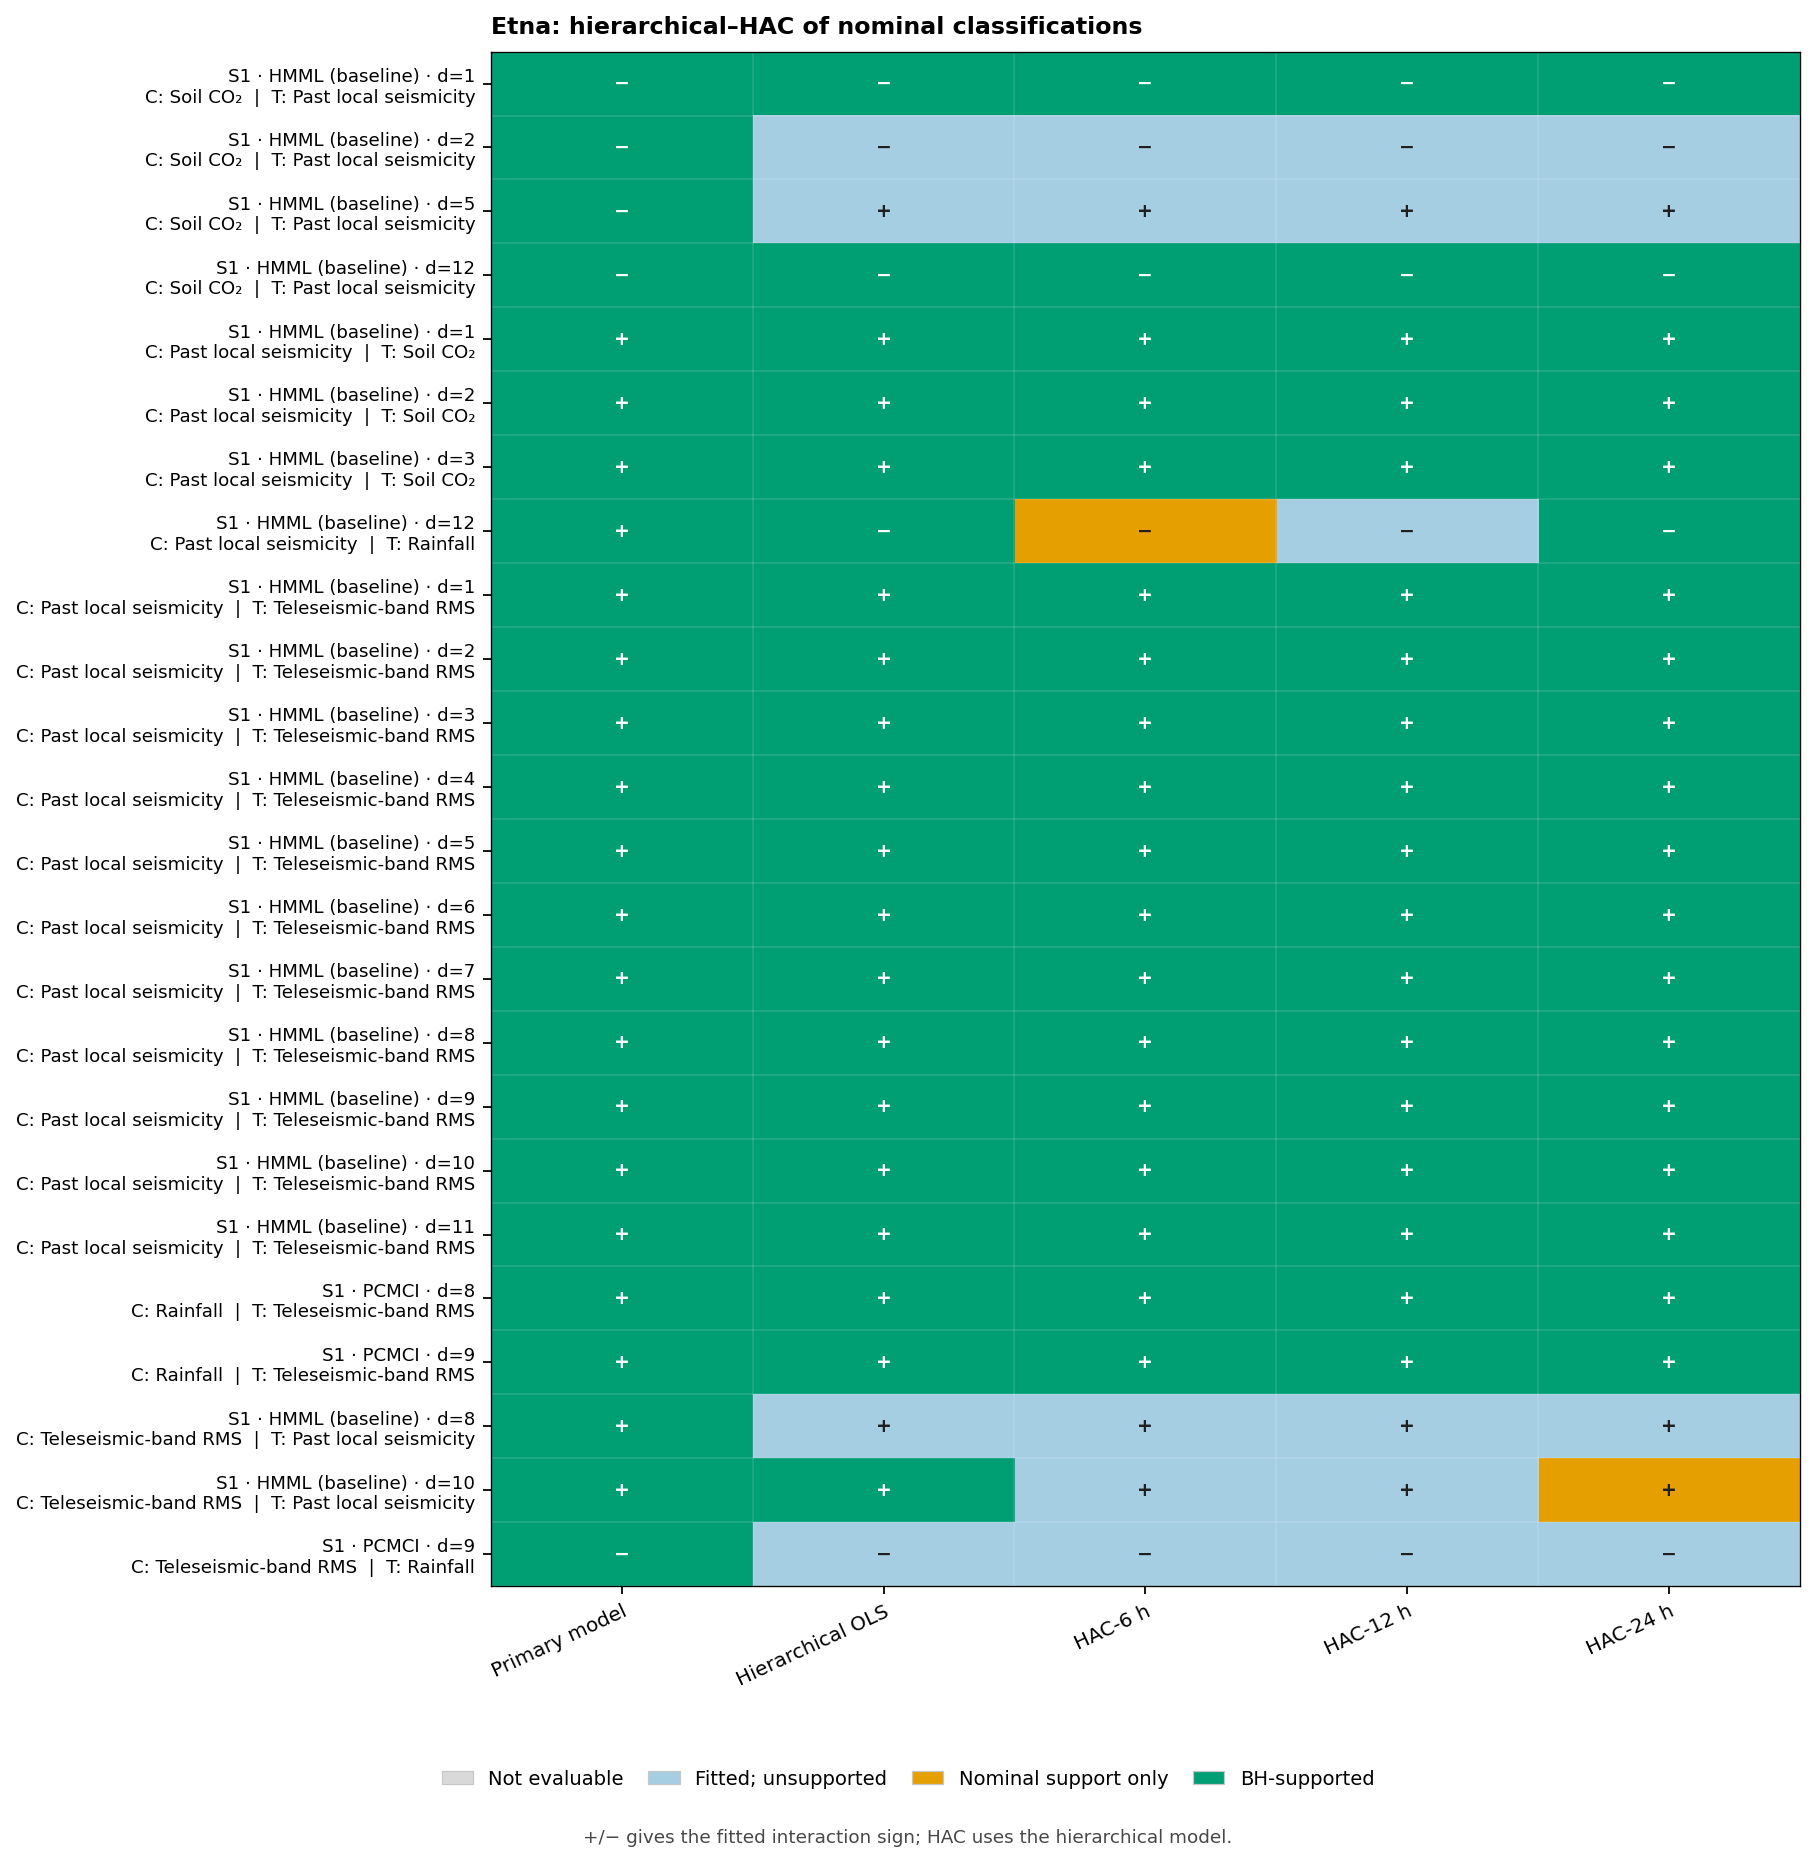

In [3]:
experiment_grid, all_diagnostics = run_unique_split_grid(
    analysis.X_model,
    analysis.X_mean,
    analysis.workflow_template,
    analysis.split_summary,
    run_one=run_one,
    run_specs=COMPACT_RUN_SPECS,
    lags=LAG_GRID,
    cond_ind_test=COND_IND_TEST,
    metadata={
        "case_pre_days": CASE_PRE_DAYS,
        "case_post_days": CASE_POST_DAYS,
        "reference_days": REFERENCE_DAYS,
        "alpha": ALPHA,
        "pcmci_pc_alpha": PCMCI_PC_ALPHA,
        "pcmci_plus_pc_alpha": PCMCI_PLUS_PC_ALPHA,
        "pcmci_alpha_level": PCMCI_ALPHA_LEVEL,
        "pcmci_fdr_method": PCMCI_FDR_METHOD,
        "conditional_independence_test": COND_IND_TEST,
        "hac_lags": HAC_LAGS,
    }
)

expected_rows = (
    len(analysis.unique_splits)
    * len(LAG_GRID)
    * len(COMPACT_RUN_SPECS)
)
if len(experiment_grid) != expected_rows:
    raise RuntimeError(
        f"Incomplete unique-partition grid: expected {expected_rows} rows, "
        f"received {len(experiment_grid)}."
    )

backend_summary = backend_split_summary(
    experiment_grid,
    lag_count=len(LAG_GRID),
    diagnostics=all_diagnostics,
)
pair_summary = pair_split_lag_summary(
    all_diagnostics,
    experiment_grid,
    lags=LAG_GRID,
    variable_labels=VARIABLE_LABELS,
)
warning_table = warning_summary(experiment_grid)
warning_pattern_table = warning_pattern_summary(
    experiment_grid,
    all_diagnostics,
)

show_table(backend_summary, "Backend behaviour within each unique partition")
show_table(pair_summary, "Nominally supported pair stability across unique partitions and lag orders")
show_table(
    multiplicity_audit_summary(all_diagnostics),
    "Model moderation decisions and secondary BH audit",
)
sensitivity_summary = moderation_summary(
    all_diagnostics,
    hac_lags=HAC_LAGS,
)
show_table(
    sensitivity_summary,
    "Hierarchical–HAC moderation sensitivity",
)

if not warning_table.empty:
    show_table(warning_pattern_table, "Warning patterns by lag-order range")

hmml_grid = experiment_grid.loc[
    experiment_grid["backend"].eq("hmml")
].copy()

hmml_diagnostics = all_diagnostics.loc[
    all_diagnostics["backend"].eq("hmml")
].copy()

plot_pair_stability_heatmap(
    hmml_diagnostics,
    hmml_grid,
    lags=LAG_GRID,
    variable_labels=VARIABLE_LABELS,
    backend_labels={"hmml": "HMML (baseline)"},
    title="Etna: HMML ordered-pair stability",
    filename="etna_hmml_pair_stability_heatmap",
    save_dir=FIGURES_DIR,
)

plot_moderation_heatmap(
    all_diagnostics,
    hac_lags=HAC_LAGS,
    variable_labels=VARIABLE_LABELS,
    title="Etna: hierarchical–HAC of nominal classifications",
    filename="etna_hierarchical_hac",
    save_dir=FIGURES_DIR,
)

errors = experiment_grid.loc[experiment_grid["error"].notna()]
if not errors.empty:
    show_table(
        errors[["split_id", "backend", "lag", "error"]],
        "Execution errors",
    )

if SHOW_FULL_GRID:
    show_table(experiment_grid.drop(columns="error"), "Complete unique-partition grid")

## Automatic VAR lag-order choices

VAR-AIC and VAR-BIC are conventional automatic references. Their selected orders are already contained in the 1–12 grid; the table below reports the actual Cause–Trigger outcome at those orders for every backend and unique partition.

In [4]:
automatic_lag_summary = automatic_lag_outcome_table(
    experiment_grid,
    all_diagnostics,
    analysis.lag_references,
    variable_labels=VARIABLE_LABELS,
)
show_table(
    automatic_lag_summary,
    "Cause–Trigger outcomes at VAR-AIC and VAR-BIC lag orders",
)

Criterion,Selected d (h),Search boundary,Partition,Minimum-I2 support,Backend,Outcome
AIC,2,False,S1,"[36, 48, 60, 72]",HMML (baseline),Nominally supported: Cause: Soil CO₂; trigger: Past local seismicity [Lagged]; Cause: Past local seismicity; trigger: Soil CO₂ [Lagged]; Cause: Past local seismicity; trigger: Teleseismic-band RMS [Lagged]
AIC,2,False,S1,"[36, 48, 60, 72]",PCMCI,No lagged non-target B2 variables are available to construct V.
AIC,2,False,S1,"[36, 48, 60, 72]",PCMCI+ with eligible exploratory τ=0 triggers,No lagged non-target B2 variables are available to construct V.
BIC,1,False,S1,"[36, 48, 60, 72]",HMML (baseline),Nominally supported: Cause: Soil CO₂; trigger: Past local seismicity [Lagged]; Cause: Past local seismicity; trigger: Soil CO₂ [Lagged]; Cause: Past local seismicity; trigger: Teleseismic-band RMS [Lagged]
BIC,1,False,S1,"[36, 48, 60, 72]",PCMCI,No lagged non-target B2 variables are available to construct V.
BIC,1,False,S1,"[36, 48, 60, 72]",PCMCI+ with eligible exploratory τ=0 triggers,No lagged non-target B2 variables are available to construct V.


## Saved audit outputs

Three CSV files are written: unique run-level results, all moderation diagnostics (including the primary, hierarchical and HAC specifications with separate BH audits), and a consolidated analysis summary that also records the mean-shift, sensitivity and lag-order sensitivity diagnostics.

In [5]:
if SAVE_RESULTS:
    saved_files = export_audit_csvs(
        results_dir=RESULTS_DIR,
        case_prefix=CASE.name.lower(),
        experiment_grid=experiment_grid,
        diagnostics=all_diagnostics,
        design=analysis.design_summary,
        lag_references=analysis.lag_references,
        automatic_lag_summary=automatic_lag_summary,
        split_summary=analysis.split_summary,
        backend_summary=backend_summary,
        pair_summary=pair_summary,
        warning_table=warning_table,
        variable_labels=VARIABLE_LABELS,
        role_shift_table=role_shift_table,
        sensitivity_summary=sensitivity_summary,
    )
    show_table(saved_files, "Saved audit files")

File,Contents,Rows
etna_cause_trigger_all_runs.csv,"Every unique split × backend × maximum-lag-order run, including supporting minimum-I2 values, candidate sets, pairs, warnings, stop reasons, and errors.",36
etna_cause_trigger_moderation_diagnostics.csv,"Every evaluated cause-trigger combination, nominal paper-compatible decision, trigger source, hierarchical--HAC sensitivities, complete test statistics, and specification-wise case-wide BH audits.",44
etna_cause_trigger_summary.csv,"Design, split stability, automatic AIC/BIC outcomes, backend behaviour, pair stability, mean-shift role diagnostics, warning audit, descriptive multiplicity audit, hierarchical--HAC sensitivity, and any lag-order sensitivity check.",48
